In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import joblib

In [4]:
df = pd.read_csv(r'/Users/arseny/Heart-Failure-Prediction/data/processed/heart_ready.csv')

In [5]:
X = df.drop('HeartDisease', axis = 1)
y = df['HeartDisease']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


In [7]:
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(random_state=42, probability=True))
    ]),
    'Decision Tree': Pipeline([
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    'AdaBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', AdaBoostClassifier(random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
    ]),
    'CatBoost': Pipeline([
        ('classifier', CatBoostClassifier(random_state=42, verbose=0, allow_writing_files=False))
    ])
}

In [8]:
results = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }
    print(f"{name}:")
    print(f"   Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"   Precision: {results[name]['precision']:.4f}")
    print(f"   Recall:    {results[name]['recall']:.4f}")
    print(f"   F1-score:  {results[name]['f1']:.4f}")

Logistic Regression:
   Accuracy:  0.8804
   Precision: 0.8922
   Recall:    0.8922
   F1-score:  0.8922
SVM:
   Accuracy:  0.8750
   Precision: 0.8835
   Recall:    0.8922
   F1-score:  0.8878
Decision Tree:
   Accuracy:  0.7772
   Precision: 0.8211
   Recall:    0.7647
   F1-score:  0.7919
Random Forest:
   Accuracy:  0.8696
   Precision: 0.8824
   Recall:    0.8824
   F1-score:  0.8824
AdaBoost:
   Accuracy:  0.8859
   Precision: 0.9091
   Recall:    0.8824
   F1-score:  0.8955
XGBoost:
   Accuracy:  0.8478
   Precision: 0.8700
   Recall:    0.8529
   F1-score:  0.8614
CatBoost:
   Accuracy:  0.8913
   Precision: 0.9100
   Recall:    0.8922
   F1-score:  0.9010


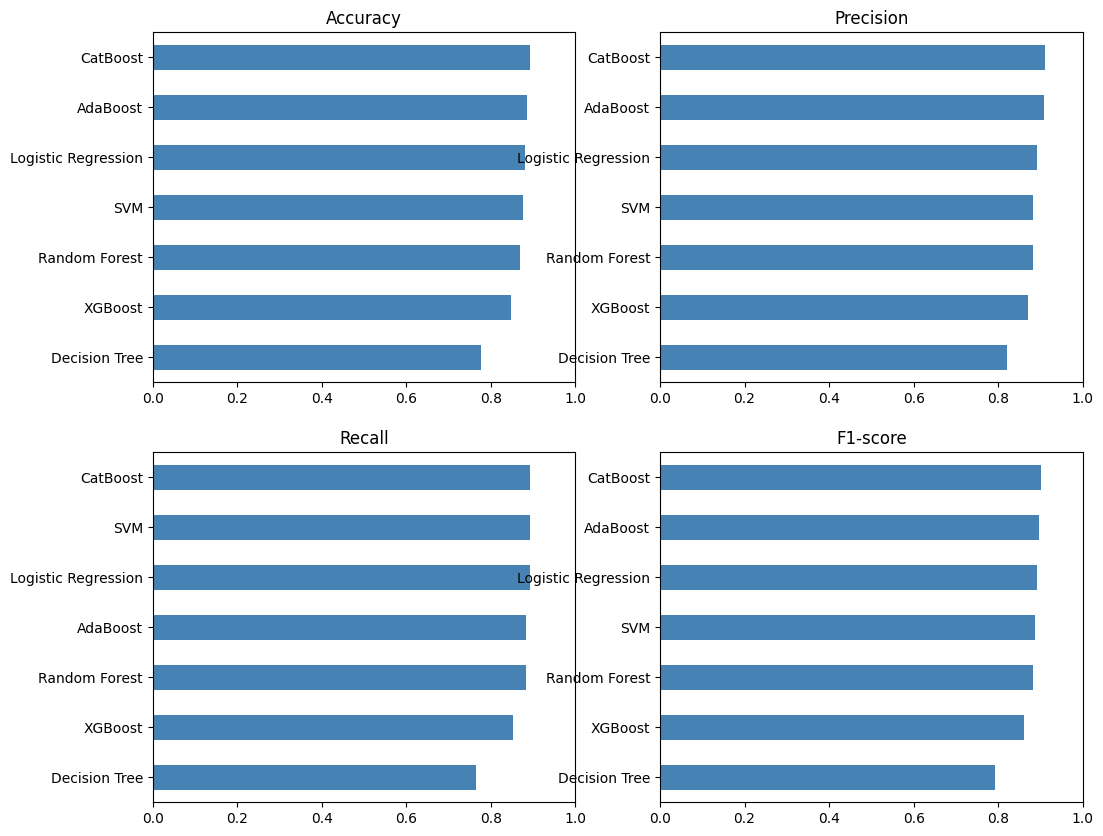

In [64]:
results_df = pd.DataFrame(results).T
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-score']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    row, col = i // 2, i % 2
    results_df[metric].sort_values().plot(kind='barh', ax=axes[row, col], color='steelblue')
    axes[row, col].set_title(title)
    axes[row, col].set_xlim(0, 1)

plt.show()

In [65]:

cv_results = {}

for name, pipeline in pipelines.items():
    print(f"\n {name}...")
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')
    cv_results[name] = {
        'mean_f1': cv_scores.mean(),
        'std_f1': cv_scores.std()
    }
    print(f"   Average F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


 Logistic Regression...
   Average F1: 0.8669 (+/- 0.0276)

 SVM...
   Average F1: 0.8811 (+/- 0.0309)

 Decision Tree...
   Average F1: 0.7987 (+/- 0.0408)

 Random Forest...
   Average F1: 0.8734 (+/- 0.0302)

 AdaBoost...
   Average F1: 0.8588 (+/- 0.0269)

 XGBoost...
   Average F1: 0.8727 (+/- 0.0318)

 CatBoost...
   Average F1: 0.8816 (+/- 0.0321)


In [76]:
print("\n Random Forest GridSearch...")
param_grid_rf = {
    'classifier__n_estimators': [64, 100,120,160],
    'classifier__max_depth': [3, 5, 10],
    'classifier__min_samples_split': [2, 5],
}

grid_rf = GridSearchCV(
    pipelines['Random Forest'],
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train, y_train)

print(f"   Best parametrs: {grid_rf.best_params_}")
print(f"   Best F1 (CV): {grid_rf.best_score_:.4f}")
best_rf = grid_rf.best_estimator_

print("\n XGBoost GridSearch...")
param_grid_xgb = {
    'classifier__n_estimators': [50,80,120,160],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.1, 0.3]
}

grid_xgb = GridSearchCV(
    pipelines['XGBoost'],
    param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_xgb.fit(X_train, y_train)

print(f"   Best parametrs: {grid_xgb.best_params_}")
print(f"   Best F1 (CV): {grid_xgb.best_score_:.4f}")
best_xgb = grid_xgb.best_estimator_



print("\n CatBoost GridSearch...")
param_grid_cb = {
    'classifier__iterations': [100, 200, 300],
    'classifier__depth': [4, 6, 8, 10],
    'classifier__learning_rate': [0.01, 0.03, 0.1],
    'classifier__l2_leaf_reg': [1, 3, 5],
}


grid_cb = GridSearchCV(
    pipelines['CatBoost'],
    param_grid_cb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_cb.fit(X_train, y_train)

print(f"   Best parametrs: {grid_cb.best_params_}")
print(f"   Best F1 (CV): {grid_cb.best_score_:.4f}")
best_cb = grid_cb.best_estimator_


 Random Forest GridSearch...
   Best parametrs: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 64}
   Best F1 (CV): 0.8802

 XGBoost GridSearch...
   Best parametrs: {'classifier__learning_rate': 0.3, 'classifier__max_depth': 4, 'classifier__n_estimators': 80}
   Best F1 (CV): 0.8877

 CatBoost GridSearch...
   Best parametrs: {'classifier__depth': 4, 'classifier__iterations': 200, 'classifier__l2_leaf_reg': 5, 'classifier__learning_rate': 0.1}
   Best F1 (CV): 0.8892


In [67]:

param_grid_svm = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.1, 0.01],
    'classifier__kernel': ['rbf', 'linear']
}

grid_svm = GridSearchCV(
    pipelines['SVM'],
    param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

for param, value in grid_svm.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n Best F1 (CV): {grid_svm.best_score_:.4f}")

best_svm = grid_svm.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits
   classifier__C: 10
   classifier__gamma: 0.01
   classifier__kernel: rbf

 Best F1 (CV): 0.8906


In [68]:
final_models = {}

pipelines['Logistic Regression'].fit(X_train, y_train)
pipelines['SVM'].fit(X_train, y_train)
pipelines['Decision Tree'].fit(X_train, y_train)
pipelines['AdaBoost'].fit(X_train, y_train)

best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)
best_cb.fit(X_train, y_train)
best_svm.fit(X_train,y_train)

final_models = {
    'Logistic Regression': pipelines['Logistic Regression'],
    'SVM (tuned)': best_svm,
    'Decision Tree': pipelines['Decision Tree'],
    'AdaBoost': pipelines['AdaBoost'],
    'Random Forest (tuned)': best_rf,
    'XGBoost (tuned)': best_xgb,
    'CatBoost (tuned)': best_cb
}

final_results = {}

for name, model in final_models.items():
    y_pred = model.predict(X_test)
    final_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }
    
    print(f"\n🔹 {name}:")
    print(f"   Accuracy: {final_results[name]['accuracy']:.4f}")
    print(f"   F1-score: {final_results[name]['f1']:.4f}")


🔹 Logistic Regression:
   Accuracy: 0.8804
   F1-score: 0.8922

🔹 SVM (tuned):
   Accuracy: 0.8696
   F1-score: 0.8835

🔹 Decision Tree:
   Accuracy: 0.7772
   F1-score: 0.7919

🔹 AdaBoost:
   Accuracy: 0.8859
   F1-score: 0.8955

🔹 Random Forest (tuned):
   Accuracy: 0.8696
   F1-score: 0.8824

🔹 XGBoost (tuned):
   Accuracy: 0.8696
   F1-score: 0.8812

🔹 CatBoost (tuned):
   Accuracy: 0.8804
   F1-score: 0.8911


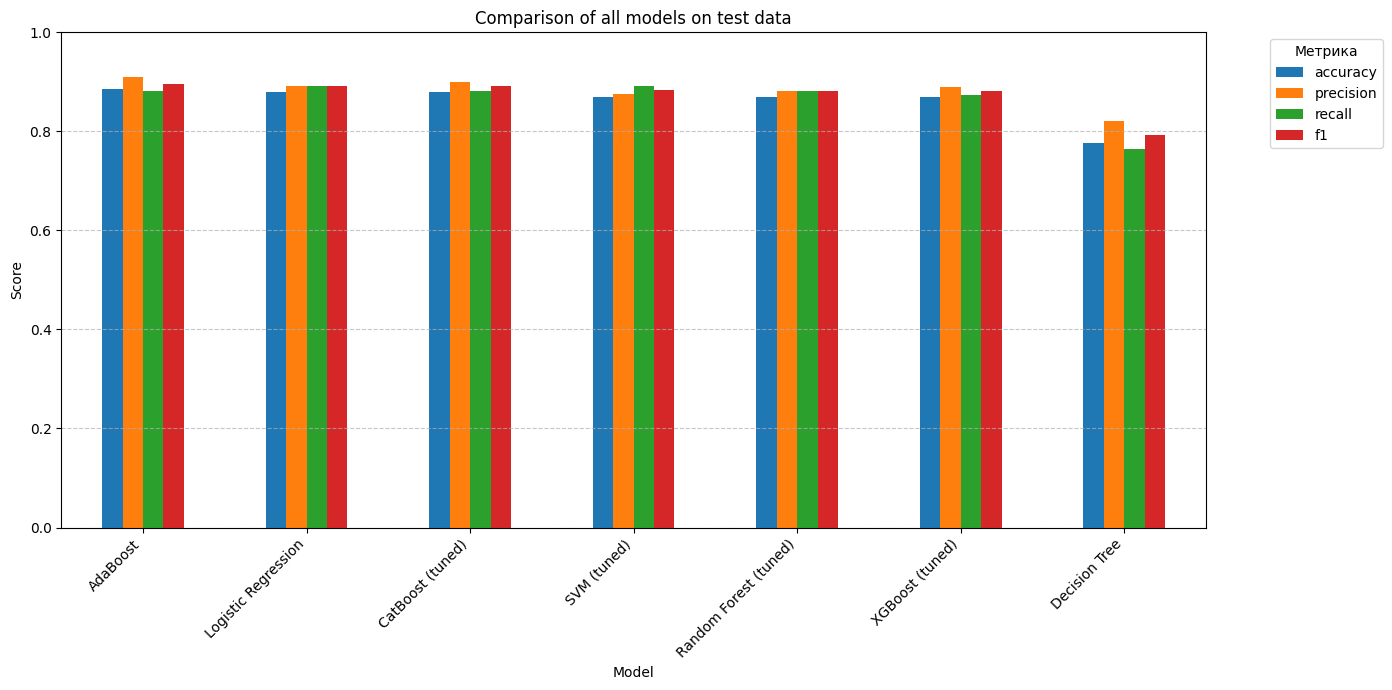


 FINAL RATING OF MODELS BY F1-Score:
                           f1  accuracy  recall  precision
AdaBoost               0.8955    0.8859  0.8824     0.9091
Logistic Regression    0.8922    0.8804  0.8922     0.8922
CatBoost (tuned)       0.8911    0.8804  0.8824     0.9000
SVM (tuned)            0.8835    0.8696  0.8922     0.8750
Random Forest (tuned)  0.8824    0.8696  0.8824     0.8824
XGBoost (tuned)        0.8812    0.8696  0.8725     0.8900
Decision Tree          0.7919    0.7772  0.7647     0.8211


In [71]:
final_df = pd.DataFrame(final_results).T.sort_values('f1', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
final_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', ax=ax)
ax.set_title('Comparison of all models on test data')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(title='Метрика', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n FINAL RATING OF MODELS BY F1-Score:")
print(final_df[['f1', 'accuracy', 'recall', 'precision']].round(4).to_string())

In [9]:
joblib.dump(pipelines['AdaBoost'], '../models/adaboost_model.pkl')

['../models/adaboost_model.pkl']